# Heart Dataset Cleaning and Initial Exploratory Data Analysis

## Objective
This notebook is cleaning, validating, and exploring the heart disease dataset in order to identify cardiovascular risk patterns that can later be compared with PCOS-related features in the broader MSc study. The notebook is focusing on producing a trustworthy cardiovascular reference cohort rather than building any predictive model at this stage.

The analysis is beginning with the raw `heart.csv` dataset and is then restricting attention to a deduplicated female cohort. This choice is supporting later comparison with the PCOS datasets, while still acknowledging that the heart dataset includes women beyond the typical reproductive-age range represented in the PCOS study.

## Research Context
The wider thesis is investigating early, practical, and low-burden screening for PCOS using routine clinical and lifestyle features. Within that context, cardiovascular variables such as age, blood pressure, cholesterol, and heart-rate patterns are important because PCOS is often discussed alongside cardiometabolic risk. This notebook is therefore preparing a cleaned heart-disease comparison dataset that can later be used in the association study without blending it directly into the PCOS training workflow.

## What This Notebook Is Doing
This notebook is:
- loading and auditing the raw heart dataset
- documenting heavy duplication in the source file and removing exact duplicates
- filtering to the female comparison cohort
- standardizing cardiovascular feature names for clarity and consistency
- validating ranges and conditional missing-value handling
- producing initial univariate and bivariate EDA plots
- exporting the cleaned female heart cohort for later comparison with PCOS-related features

## Expected Output
The main cleaned output of this notebook is the deduplicated female cohort saved as:

`./cleaned_data/heart_cleaned.csv`

Supporting outputs are also being produced, including a cleaning log, a compact quality summary, and diagnostic figures saved to `./images/`.

## Notebook Structure
The sections that are following are being organized as a step-by-step cleaning and exploratory workflow:

1. **Reproducibility Setup and Path Configuration**  
   The notebook environment and file paths are being resolved for stable execution.

2. **Data Loading and Initial Inspection**  
   The raw cardiovascular dataset is being inspected for schema, missingness, duplication, and ranges.

3. **Cleaning and Cohort Definition**  
   Exact duplicates are being removed, the female comparison cohort is being selected, and the columns are being standardized.

4. **Validation and Initial EDA**  
   The cleaned cardiovascular cohort is being validated and visualized through univariate, bivariate, and correlation analyses.

5. **Dataset Export and Observational Summary**  
   The cleaned female heart cohort is being saved and the main cardiovascular observations are being summarized for later PCOS comparison.

## Reproducibility Note
All paths in this notebook are being kept relative to the project structure, and every material cleaning decision is being documented so the workflow can be rerun and audited later.

## Reproducibility Setup and Path Configuration

This section is preparing the notebook environment, importing the required libraries, and resolving the project directories used for cleaned data and figure exports.

In [1]:
# Importing the libraries that are supporting data cleaning, validation, and visualization.
from pathlib import Path
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Importing seaborn when it is available improves the default plot styling, while a matplotlib fallback keeps the notebook portable.
try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='notebook')
except ImportError:
    sns = None
    plt.style.use('seaborn-v0_8-whitegrid')

# Setting display options keeps the cleaned cardiovascular table easier to inspect in wide notebook outputs.
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

# Fixing a seed now preserves reproducibility for any later sampling or stochastic checks.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Resolving the project root dynamically allows this notebook to run from the repo root or the notebooks directory.
def resolve_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / 'data' / 'heart.csv').exists():
            return candidate
    raise FileNotFoundError('The heart dataset could not be located relative to the current working directory.')

PROJECT_ROOT = resolve_project_root()
DATA_PATH = PROJECT_ROOT / 'data' / 'heart.csv'
CLEANED_DIR = PROJECT_ROOT / 'cleaned_data'
IMAGE_DIR = PROJECT_ROOT / 'images'

# Creating the output directories keeps the export steps idempotent across reruns.
CLEANED_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

display(Markdown(f'**Project root:** `{PROJECT_ROOT}`'))
display(Markdown(f'**Raw heart dataset:** `{DATA_PATH}`'))
display(Markdown(f'**Cleaned data directory:** `{CLEANED_DIR}`'))
display(Markdown(f'**Image directory:** `{IMAGE_DIR}`'))

**Project root:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic`

**Raw heart dataset:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\data\heart.csv`

**Cleaned data directory:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data`

**Image directory:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images`

## Data Loading and Initial Inspection

The raw heart dataset is now being loaded and audited for structure, missingness, duplication, and broad distribution ranges before any cleaning decisions are being applied.

In [2]:
# Loading the raw heart dataset provides the baseline table for the cleaning and cohort-definition workflow.
df_raw = pd.read_csv(DATA_PATH)

# Displaying the first rows provides a quick check of the schema and coded cardiovascular variables.
df_raw.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.000,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.400,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.800,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.800,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.200,1,2,2,0


In [3]:
# Capturing dataframe info in a text buffer makes the schema report easier to show inside the notebook.
info_buffer = io.StringIO()
df_raw.info(buf=info_buffer)

# Building compact inspection tables keeps the initial audit readable and suitable for thesis-style reporting.
raw_shape_df = pd.DataFrame({'metric': ['rows', 'columns'], 'value': [df_raw.shape[0], df_raw.shape[1]]})
raw_missing_summary = (
    pd.DataFrame({'column': df_raw.columns, 'missing_count': df_raw.isna().sum().values, 'missing_percentage': (df_raw.isna().sum().values / len(df_raw)) * 100})
    .sort_values(['missing_count', 'column'], ascending=[False, True])
    .reset_index(drop=True)
)
raw_duplicate_rows = int(df_raw.duplicated().sum())
range_snapshot_df = pd.DataFrame(
    {
        'column': ['age', 'trestbps', 'chol', 'thalach', 'oldpeak'],
        'minimum': [df_raw['age'].min(), df_raw['trestbps'].min(), df_raw['chol'].min(), df_raw['thalach'].min(), df_raw['oldpeak'].min()],
        'maximum': [df_raw['age'].max(), df_raw['trestbps'].max(), df_raw['chol'].max(), df_raw['thalach'].max(), df_raw['oldpeak'].max()],
    }
)

display(Markdown('### Raw Dataset Shape'))
display(raw_shape_df)
display(Markdown('### Raw Data Types'))
print(info_buffer.getvalue())
display(Markdown('### Descriptive Statistics'))
display(df_raw.describe().T)
display(Markdown('### Missing-Value Summary'))
display(raw_missing_summary)
display(Markdown('### Duplicate Summary'))
display(pd.DataFrame({'check': ['Exact duplicate rows'], 'count': [raw_duplicate_rows]}))
display(Markdown('### Range Snapshot for Key Variables'))
display(range_snapshot_df)

### Raw Dataset Shape

,metric,value
0,rows,1025
1,columns,14


### Raw Data Types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB



### Descriptive Statistics

...

,column,missing_count,missing_percentage
0,age,0,0.000
1,ca,0,0.000
2,chol,0,0.000
3,cp,0,0.000
4,exang,0,0.000
5,fbs,0,0.000
6,oldpeak,0,0.000
7,restecg,0,0.000
8,sex,0,0.000
9,slope,0,0.000


### Duplicate Summary

,check,count
0,Exact duplicate rows,723


### Range Snapshot for Key Variables

,column,minimum,maximum
0,age,29.000,77.000
1,trestbps,94.000,200.000
2,chol,126.000,564.000
3,thalach,71.000,202.000
4,oldpeak,0.000,6.200


## Cleaning and Female Cohort Definition

This section is removing the heavy duplication in the raw file, restricting the data to the female comparison cohort, standardizing the schema, and preparing the cleaned cardiovascular dataset used in later analyses.

In [4]:
# Copying the raw dataframe keeps the import intact so later summaries can compare the raw and cleaned states directly.
df = df_raw.copy()
transformation_log = []

# Recording each material change keeps the heart-cleaning workflow transparent and exportable.
def log_transformation(step: str, detail: str, affected_items: int) -> None:
    transformation_log.append({'step': step, 'detail': detail, 'affected_items': affected_items})

# Converting all columns to numeric is appropriate because this heart dataset is fully coded with numeric fields.
for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Removing exact duplicates before cohort filtering ensures that all downstream summaries use unique patient records.
duplicate_rows_removed = int(df.duplicated().sum())
if duplicate_rows_removed:
    df = df.drop_duplicates().copy()
    log_transformation('Removed duplicate rows', 'Dropped exact duplicate records from the raw heart dataset before subgroup filtering.', duplicate_rows_removed)

# Restricting to female records creates the cardiovascular comparison cohort used later alongside the PCOS datasets.
female_rows_before_filter = len(df)
df = df.loc[df['sex'] == 0].copy()
female_rows_selected = len(df)
log_transformation('Filtered female cohort', 'Selected only female records using sex == 0.', female_rows_selected)

# Renaming the coded cardiovascular columns improves readability and makes later cross-dataset comparison easier.
rename_map = {
    'sex': 'sex_code',
    'cp': 'chest_pain_type',
    'trestbps': 'resting_bp',
    'chol': 'cholesterol',
    'fbs': 'fasting_blood_sugar_flag',
    'restecg': 'resting_ecg_result',
    'thalach': 'max_heart_rate',
    'exang': 'exercise_induced_angina',
    'oldpeak': 'st_depression',
    'ca': 'num_major_vessels',
    'thal': 'thalassemia_code',
    'target': 'heart_disease_target',
}
rename_log = pd.DataFrame({'original_name': list(rename_map.keys()), 'standardized_name': list(rename_map.values())})
df = df.rename(columns=rename_map)
log_transformation('Standardized column names', 'Renamed coded cardiovascular fields to clearer analysis-friendly names.', len(rename_map))

# Applying conservative sanity ranges helps identify values that are implausible enough to warrant missing-value treatment.
range_rules = {
    'age': (18, 100),
    'resting_bp': (70, 260),
    'cholesterol': (100, 700),
    'max_heart_rate': (50, 230),
    'st_depression': (0, 10),
}
range_issues = []
for column, (lower_bound, upper_bound) in range_rules.items():
    invalid_mask = df[column].notna() & ((df[column] < lower_bound) | (df[column] > upper_bound))
    invalid_count = int(invalid_mask.sum())
    if invalid_count:
        range_issues.append({'column': column, 'lower_bound': lower_bound, 'upper_bound': upper_bound, 'flagged_rows': invalid_count})
        df.loc[invalid_mask, column] = np.nan
        log_transformation('Applied range sanity checks', f'Set implausible values to missing in {column}.', invalid_count)

# Imputing only when cleaning creates missing values keeps this step conditional, which matches the raw no-missing baseline.
binary_or_coded_columns = ['sex_code', 'chest_pain_type', 'fasting_blood_sugar_flag', 'resting_ecg_result', 'exercise_induced_angina', 'slope', 'num_major_vessels', 'thalassemia_code', 'heart_disease_target']
continuous_columns = [column for column in df.columns if column not in binary_or_coded_columns]
imputation_records = []
for column in binary_or_coded_columns:
    missing_count = int(df[column].isna().sum())
    if missing_count:
        mode_values = df[column].mode(dropna=True)
        if not mode_values.empty:
            fill_value = mode_values.iloc[0]
            df[column] = df[column].fillna(fill_value)
            imputation_records.append({'column': column, 'strategy': 'mode', 'filled_count': missing_count, 'fill_value': fill_value})
            log_transformation('Imputed coded column', f'Filled missing values in {column} using the mode.', missing_count)
for column in continuous_columns:
    missing_count = int(df[column].isna().sum())
    if missing_count:
        median_value = df[column].median(skipna=True)
        if pd.notna(median_value):
            df[column] = df[column].fillna(median_value)
            imputation_records.append({'column': column, 'strategy': 'median', 'filled_count': missing_count, 'fill_value': median_value})
            log_transformation('Imputed continuous column', f'Filled missing values in {column} using the median.', missing_count)

# Casting integer-like coded columns back to integer dtype keeps the exported cohort easier to inspect and compare later.
integer_like_columns = ['sex_code', 'chest_pain_type', 'fasting_blood_sugar_flag', 'resting_ecg_result', 'exercise_induced_angina', 'slope', 'num_major_vessels', 'thalassemia_code', 'heart_disease_target']
for column in integer_like_columns:
    series = df[column].dropna().astype(float)
    if not series.empty and np.isclose(series % 1, 0).all():
        df[column] = df[column].round().astype('Int64')

range_issues_df = pd.DataFrame(range_issues)
imputation_log_df = pd.DataFrame(imputation_records)
cohort_summary_df = pd.DataFrame(
    {
        'metric': ['Raw rows', 'Raw columns', 'Duplicate rows removed', 'Unique rows after deduplication', 'Female rows retained'],
        'value': [len(df_raw), df_raw.shape[1], duplicate_rows_removed, female_rows_before_filter, female_rows_selected],
    }
)
target_distribution_df = df['heart_disease_target'].value_counts(dropna=False).rename_axis('heart_disease_target').reset_index(name='count').sort_values('heart_disease_target').reset_index(drop=True)

display(Markdown('### Rename Map'))
display(rename_log)
display(Markdown('### Cohort Summary'))
display(cohort_summary_df)
display(Markdown('### Female Cohort Target Distribution'))
display(target_distribution_df)
display(Markdown('### Conditional Imputation Log'))
display(imputation_log_df if not imputation_log_df.empty else pd.DataFrame({'message': ['No imputation was required after cleaning.']}))

### Rename Map

,original_name,standardized_name
0,sex,sex_code
1,cp,chest_pain_type
2,trestbps,resting_bp
3,chol,cholesterol
4,fbs,fasting_blood_sugar_flag
5,restecg,resting_ecg_result
6,thalach,max_heart_rate
7,exang,exercise_induced_angina
8,oldpeak,st_depression
9,ca,num_major_vessels


### Cohort Summary

,metric,value
0,Raw rows,1025
1,Raw columns,14
2,Duplicate rows removed,723
3,Unique rows after deduplication,302
4,Female rows retained,96


### Female Cohort Target Distribution

,heart_disease_target,count
0,0,24
1,1,72


### Conditional Imputation Log

,message
0,No imputation was required after cleaning.


## Validation and Initial Exploratory Data Analysis

The cleaned female cohort is now being validated and explored through univariate, bivariate, and correlation analyses. These plots are helping to identify the cardiovascular variables that are most relevant for later comparison with PCOS-related metabolic and clinical patterns.

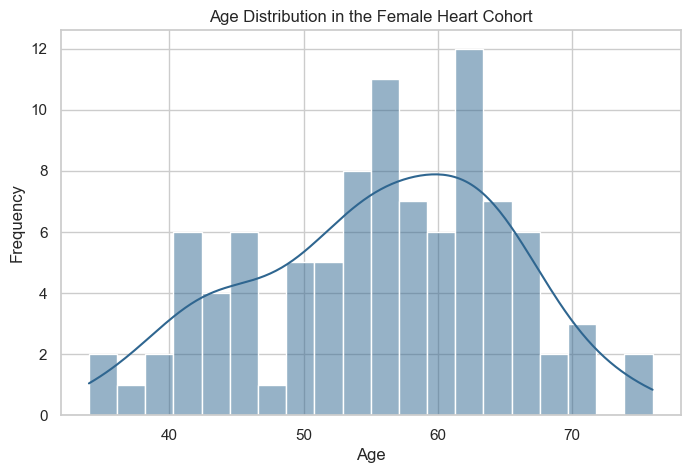

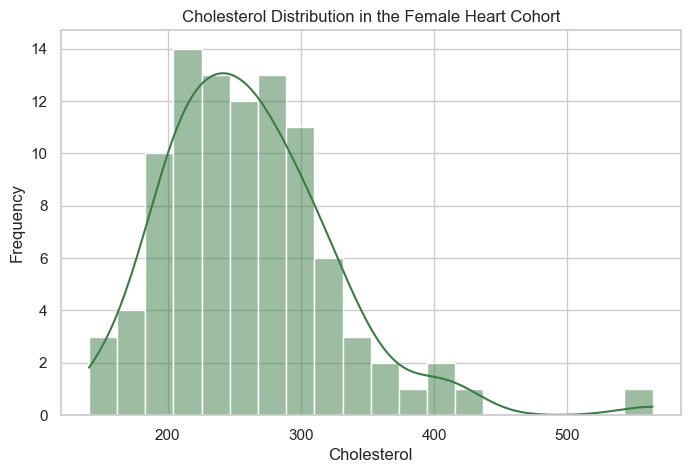

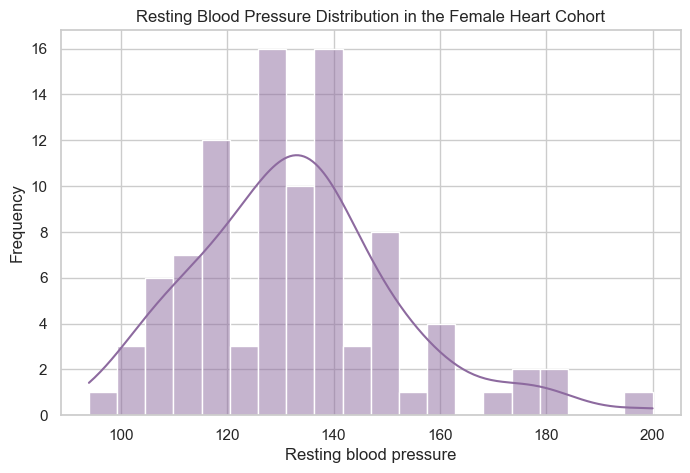

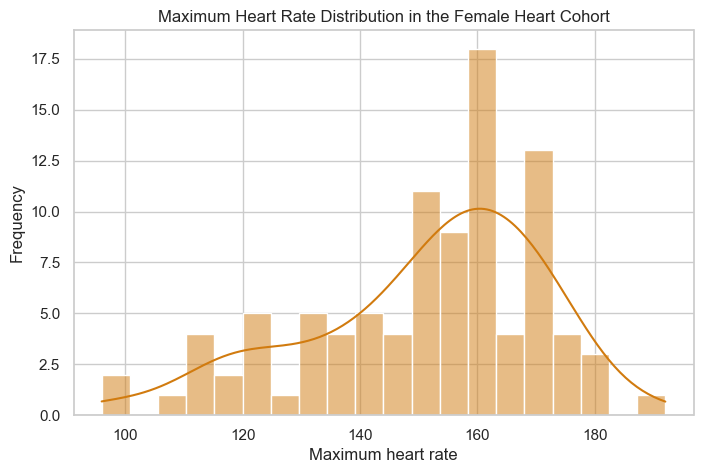

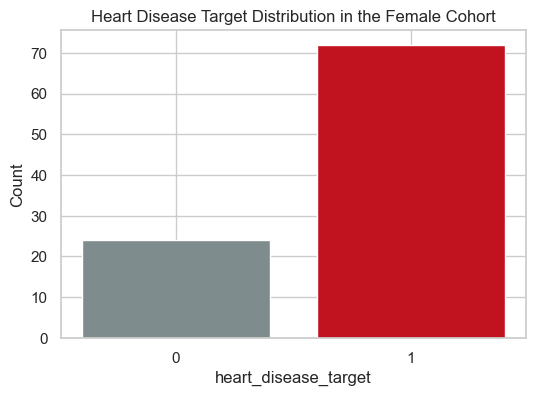

### Remaining Missingness After Cleaning

,column,missing_count,missing_percentage
0,age,0,0.000
1,chest_pain_type,0,0.000
2,cholesterol,0,0.000
3,exercise_induced_angina,0,0.000
4,fasting_blood_sugar_flag,0,0.000
5,heart_disease_target,0,0.000
6,max_heart_rate,0,0.000
7,num_major_vessels,0,0.000
8,resting_bp,0,0.000
9,resting_ecg_result,0,0.000


### Coded Field Validation

,column,unique_non_null_values
0,sex_code,0
1,chest_pain_type,"0, 1, 2, 3"
2,fasting_blood_sugar_flag,"0, 1"
3,resting_ecg_result,"0, 1, 2"
4,exercise_induced_angina,"0, 1"
5,slope,"0, 1, 2"
6,num_major_vessels,"0, 1, 2, 3"
7,thalassemia_code,"0, 1, 2, 3"
8,heart_disease_target,"0, 1"


In [5]:
# Summarizing the remaining missingness confirms whether the cleaned female cohort is ready for later comparison work.
remaining_missing_summary = (
    pd.DataFrame({'column': df.columns, 'missing_count': df.isna().sum().values, 'missing_percentage': (df.isna().sum().values / len(df)) * 100})
    .sort_values(['missing_count', 'column'], ascending=[False, True])
    .reset_index(drop=True)
)

# Displaying coded value distributions makes the cleaned categorical fields easier to audit.
coded_field_summary = pd.DataFrame(
    [
        {
            'column': column,
            'unique_non_null_values': ', '.join(map(str, sorted(pd.Series(df[column].dropna().unique()).tolist()))),
        }
        for column in ['sex_code', 'chest_pain_type', 'fasting_blood_sugar_flag', 'resting_ecg_result', 'exercise_induced_angina', 'slope', 'num_major_vessels', 'thalassemia_code', 'heart_disease_target']
    ]
)

# Saving a consistent set of figure files keeps the EDA outputs reusable in later reporting.
saved_figures = []

fig, ax = plt.subplots(figsize=(8, 5))
if sns is not None:
    sns.histplot(df['age'], kde=True, bins=20, ax=ax, color='#2f6690')
else:
    ax.hist(df['age'].dropna(), bins=20, color='#2f6690', edgecolor='white', alpha=0.9)
ax.set_title('Age Distribution in the Female Heart Cohort')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
age_distribution_path = IMAGE_DIR / 'heart_age_distribution.png'
fig.savefig(age_distribution_path, dpi=300, bbox_inches='tight')
saved_figures.append(age_distribution_path.name)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
if sns is not None:
    sns.histplot(df['cholesterol'], kde=True, bins=20, ax=ax, color='#3a7d44')
else:
    ax.hist(df['cholesterol'].dropna(), bins=20, color='#3a7d44', edgecolor='white', alpha=0.9)
ax.set_title('Cholesterol Distribution in the Female Heart Cohort')
ax.set_xlabel('Cholesterol')
ax.set_ylabel('Frequency')
cholesterol_distribution_path = IMAGE_DIR / 'heart_cholesterol_distribution.png'
fig.savefig(cholesterol_distribution_path, dpi=300, bbox_inches='tight')
saved_figures.append(cholesterol_distribution_path.name)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
if sns is not None:
    sns.histplot(df['resting_bp'], kde=True, bins=20, ax=ax, color='#8d6a9f')
else:
    ax.hist(df['resting_bp'].dropna(), bins=20, color='#8d6a9f', edgecolor='white', alpha=0.9)
ax.set_title('Resting Blood Pressure Distribution in the Female Heart Cohort')
ax.set_xlabel('Resting blood pressure')
ax.set_ylabel('Frequency')
resting_bp_distribution_path = IMAGE_DIR / 'heart_resting_bp_distribution.png'
fig.savefig(resting_bp_distribution_path, dpi=300, bbox_inches='tight')
saved_figures.append(resting_bp_distribution_path.name)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
if sns is not None:
    sns.histplot(df['max_heart_rate'], kde=True, bins=20, ax=ax, color='#d17b0f')
else:
    ax.hist(df['max_heart_rate'].dropna(), bins=20, color='#d17b0f', edgecolor='white', alpha=0.9)
ax.set_title('Maximum Heart Rate Distribution in the Female Heart Cohort')
ax.set_xlabel('Maximum heart rate')
ax.set_ylabel('Frequency')
max_heart_rate_distribution_path = IMAGE_DIR / 'heart_max_heart_rate_distribution.png'
fig.savefig(max_heart_rate_distribution_path, dpi=300, bbox_inches='tight')
saved_figures.append(max_heart_rate_distribution_path.name)
plt.show()

target_counts = df['heart_disease_target'].value_counts(dropna=False).sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(target_counts.index.astype(str), target_counts.values, color=['#7f8c8d', '#c1121f'])
ax.set_title('Heart Disease Target Distribution in the Female Cohort')
ax.set_xlabel('heart_disease_target')
ax.set_ylabel('Count')
target_distribution_path = IMAGE_DIR / 'heart_target_distribution.png'
fig.savefig(target_distribution_path, dpi=300, bbox_inches='tight')
saved_figures.append(target_distribution_path.name)
plt.show()

display(Markdown('### Remaining Missingness After Cleaning'))
display(remaining_missing_summary)
display(Markdown('### Coded Field Validation'))
display(coded_field_summary)

### Initial Observations

The cleaned female cohort is showing a class imbalance toward positive heart-disease cases, which means later interpretation should remain cautious when comparing target prevalence across datasets. The age, cholesterol, resting blood pressure, and maximum heart-rate distributions are providing the first view of the cardiovascular profile that will later be contrasted with PCOS-related metabolic patterns.

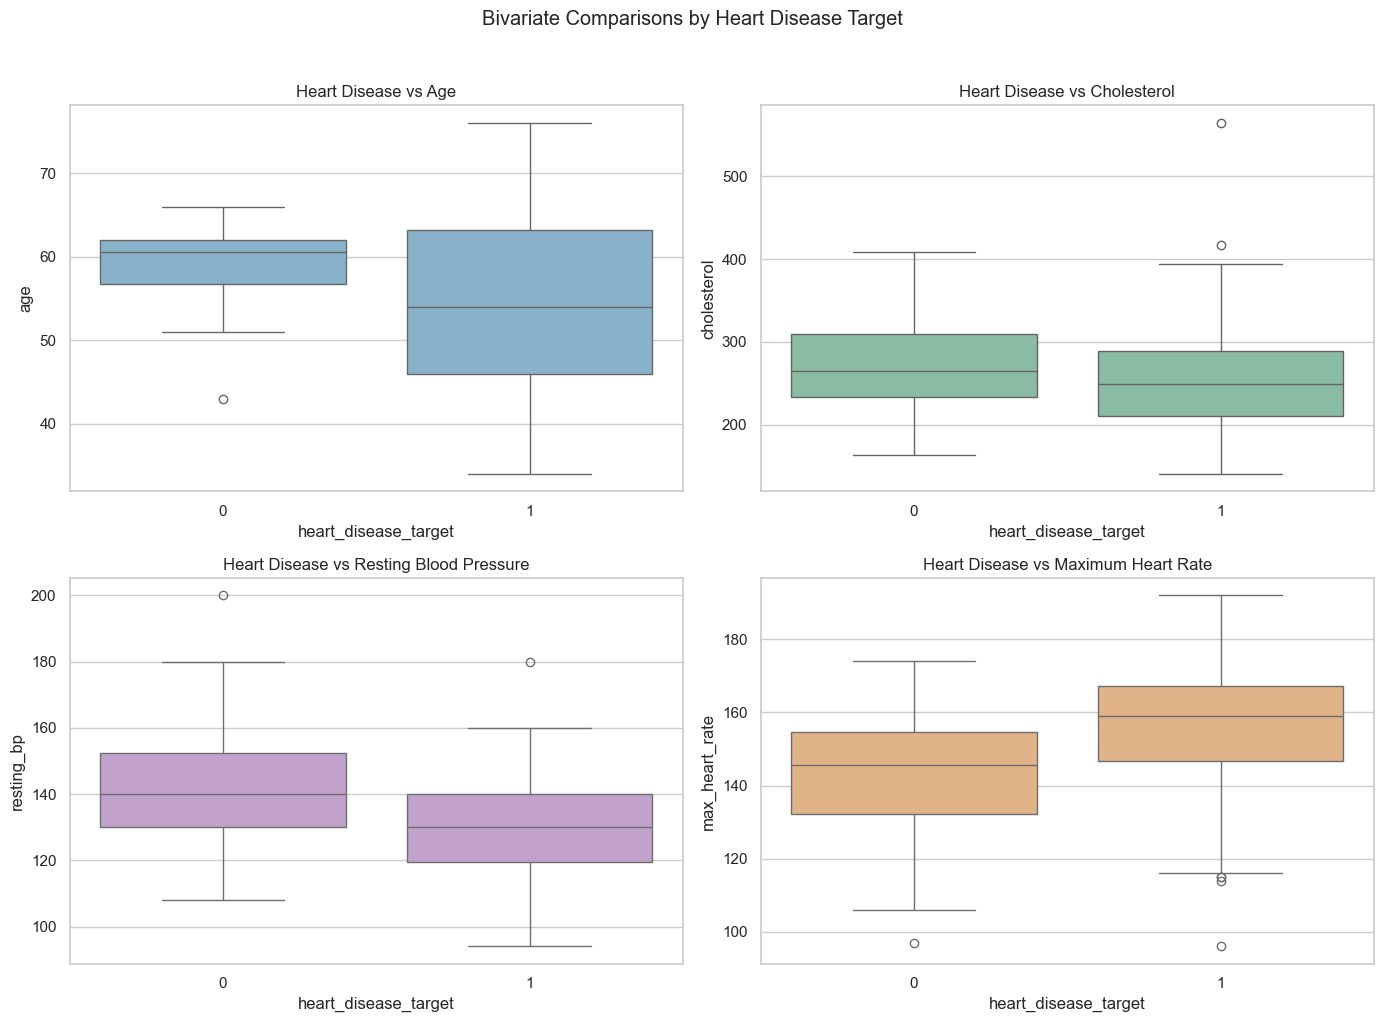

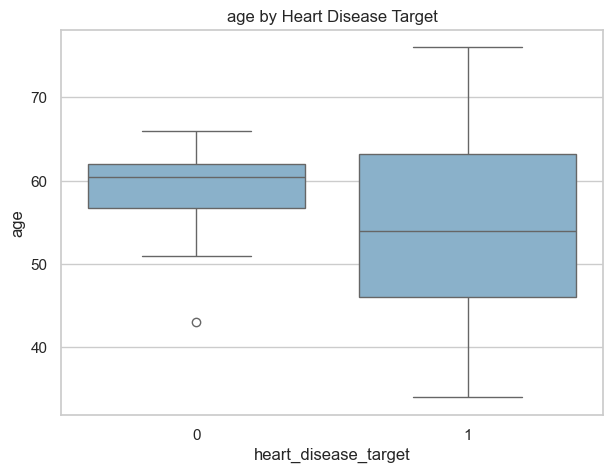

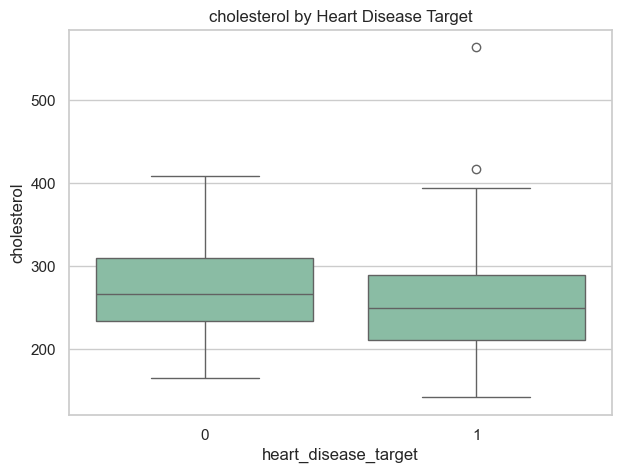

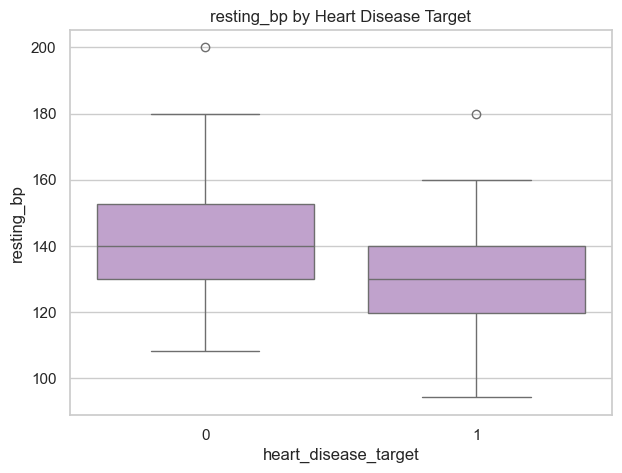

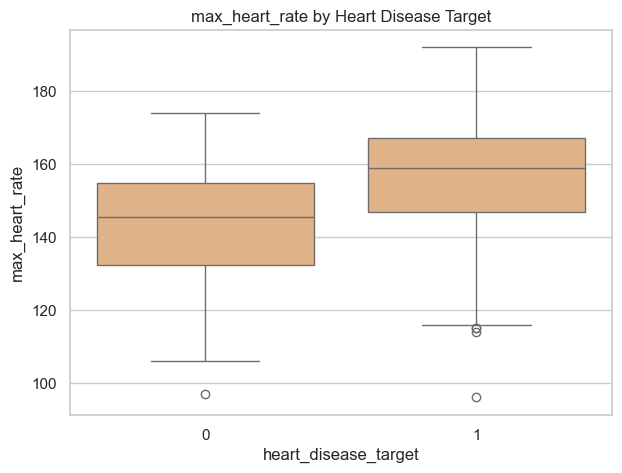

In [6]:
# Boxplots are helping to show how the main cardiovascular measures differ across heart-disease status in the female cohort.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if sns is not None:
    sns.boxplot(x='heart_disease_target', y='age', data=df, ax=axes[0, 0], color='#7fb3d5')
    sns.boxplot(x='heart_disease_target', y='cholesterol', data=df, ax=axes[0, 1], color='#82c4a5')
    sns.boxplot(x='heart_disease_target', y='resting_bp', data=df, ax=axes[1, 0], color='#c39bd3')
    sns.boxplot(x='heart_disease_target', y='max_heart_rate', data=df, ax=axes[1, 1], color='#f0b27a')
else:
    df.boxplot(column='age', by='heart_disease_target', ax=axes[0, 0])
    df.boxplot(column='cholesterol', by='heart_disease_target', ax=axes[0, 1])
    df.boxplot(column='resting_bp', by='heart_disease_target', ax=axes[1, 0])
    df.boxplot(column='max_heart_rate', by='heart_disease_target', ax=axes[1, 1])

axes[0, 0].set_title('Heart Disease vs Age')
axes[0, 1].set_title('Heart Disease vs Cholesterol')
axes[1, 0].set_title('Heart Disease vs Resting Blood Pressure')
axes[1, 1].set_title('Heart Disease vs Maximum Heart Rate')
for ax in axes.flat:
    ax.set_xlabel('heart_disease_target')
plt.suptitle('Bivariate Comparisons by Heart Disease Target', y=1.02)
plt.tight_layout()
bivariate_panel_path = IMAGE_DIR / 'heart_bivariate_panel.png'
plt.savefig(bivariate_panel_path, dpi=300, bbox_inches='tight')
saved_figures.append(bivariate_panel_path.name)
plt.show()

# Saving individual plot files as well keeps the main comparison figures easy to reuse in reports or later notebooks.
for y_column, filename, color in [
    ('age', 'heart_age_vs_target.png', '#7fb3d5'),
    ('cholesterol', 'heart_cholesterol_vs_target.png', '#82c4a5'),
    ('resting_bp', 'heart_resting_bp_vs_target.png', '#c39bd3'),
    ('max_heart_rate', 'heart_max_heart_rate_vs_target.png', '#f0b27a'),
]:
    fig, ax = plt.subplots(figsize=(7, 5))
    if sns is not None:
        sns.boxplot(x='heart_disease_target', y=y_column, data=df, ax=ax, color=color)
    else:
        df.boxplot(column=y_column, by='heart_disease_target', ax=ax)
    ax.set_title(f'{y_column} by Heart Disease Target')
    ax.set_xlabel('heart_disease_target')
    figure_path = IMAGE_DIR / filename
    fig.savefig(figure_path, dpi=300, bbox_inches='tight')
    saved_figures.append(figure_path.name)
    plt.show()

### Comparative Observations

These boxplots are helping to assess whether positive heart-disease cases in the female cohort are clustering toward older age, higher cholesterol, and elevated resting blood pressure. Even when the shifts are not extreme for every variable, the comparisons are highlighting which cardiovascular measures may be most informative when the later PCOS association notebook is comparing shared risk patterns across datasets.

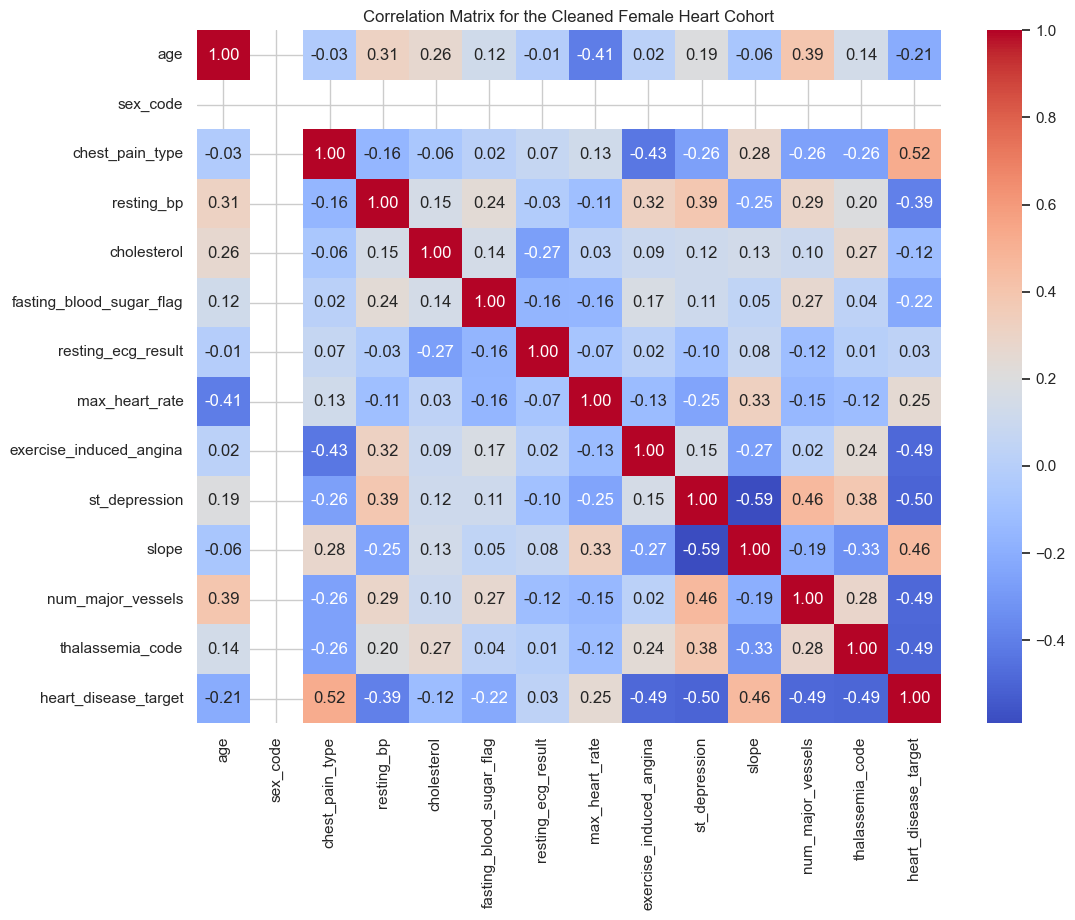

### Correlation with the Heart Disease Target

,feature,correlation_with_heart_disease_target
0,heart_disease_target,1.000
1,chest_pain_type,0.522
2,slope,0.458
3,max_heart_rate,0.252
4,resting_ecg_result,0.033
5,cholesterol,-0.122
6,age,-0.208
7,fasting_blood_sugar_flag,-0.218
8,resting_bp,-0.392
9,exercise_induced_angina,-0.487


### Saved Diagnostic Figures

,saved_figure
0,heart_age_distribution.png
1,heart_cholesterol_distribution.png
2,heart_resting_bp_distribution.png
3,heart_max_heart_rate_distribution.png
4,heart_target_distribution.png
5,heart_bivariate_panel.png
6,heart_age_vs_target.png
7,heart_cholesterol_vs_target.png
8,heart_resting_bp_vs_target.png
9,heart_max_heart_rate_vs_target.png


In [7]:
# The correlation matrix is helping to identify which cardiovascular variables move together in the cleaned female cohort.
fig, ax = plt.subplots(figsize=(12, 9))
correlation_matrix = df.corr(numeric_only=True)
if sns is not None:
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
else:
    heatmap = ax.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
    ax.set_xticks(range(len(correlation_matrix.columns)))
    ax.set_xticklabels(correlation_matrix.columns, rotation=90)
    ax.set_yticks(range(len(correlation_matrix.index)))
    ax.set_yticklabels(correlation_matrix.index)
    fig.colorbar(heatmap, ax=ax)
ax.set_title('Correlation Matrix for the Cleaned Female Heart Cohort')
correlation_matrix_path = IMAGE_DIR / 'heart_correlation_matrix.png'
fig.savefig(correlation_matrix_path, dpi=300, bbox_inches='tight')
saved_figures.append(correlation_matrix_path.name)
plt.show()

correlation_with_target = correlation_matrix['heart_disease_target'].sort_values(ascending=False).reset_index()
correlation_with_target.columns = ['feature', 'correlation_with_heart_disease_target']

display(Markdown('### Correlation with the Heart Disease Target'))
display(correlation_with_target)
display(Markdown('### Saved Diagnostic Figures'))
display(pd.DataFrame({'saved_figure': saved_figures}))

### Correlation Observations

The correlation structure is helping to identify which cardiovascular variables are most closely aligned with the heart-disease outcome in this female cohort. These relationships are especially relevant for the later PCOS-versus-cardiovascular comparison because age, cholesterol, resting blood pressure, and heart-rate behavior are among the most plausible shared risk pathways.

## Dataset Export and Cleaning Summary

The cleaned female heart cohort is now being exported together with a compact transformation log and quality summary. This is preserving a reusable comparison dataset for the later association study while keeping the cleaning workflow transparent.

In [8]:
# Converting the transformation history into a dataframe makes the cleaning record easy to inspect and export.
transformation_log_df = pd.DataFrame(transformation_log)

# Building a quality summary table provides a concise before-and-after snapshot of the cleaned cohort.
quality_summary_df = pd.DataFrame(
    {
        'check': [
            'Rows in raw dataset',
            'Columns in raw dataset',
            'Exact duplicate rows removed',
            'Unique rows after deduplication',
            'Female rows retained',
            'Columns in cleaned cohort',
            'Range flags handled',
            'Remaining missing cells after cleaning',
        ],
        'value': [
            len(df_raw),
            df_raw.shape[1],
            duplicate_rows_removed,
            female_rows_before_filter,
            len(df),
            df.shape[1],
            int(range_issues_df['flagged_rows'].sum()) if not range_issues_df.empty else 0,
            int(df.isna().sum().sum()),
        ],
    }
)

# Defining the export paths once keeps the saved outputs consistent with the project layout.
cleaned_dataset_path = CLEANED_DIR / 'heart_cleaned.csv'
transformation_log_path = CLEANED_DIR / 'heart_cleaning_log.csv'
quality_summary_path = CLEANED_DIR / 'heart_quality_summary.csv'

# Exporting the cleaned female cohort preserves the cardiovascular comparison dataset for later notebooks.
df.to_csv(cleaned_dataset_path, index=False)
transformation_log_df.to_csv(transformation_log_path, index=False)
quality_summary_df.to_csv(quality_summary_path, index=False)

display(Markdown(f'**Cleaned female heart cohort saved to:** `{cleaned_dataset_path}`'))
display(Markdown(f'**Transformation log saved to:** `{transformation_log_path}`'))
display(Markdown(f'**Quality summary saved to:** `{quality_summary_path}`'))
display(Markdown('### Cleaning Summary Table'))
display(quality_summary_df)
display(Markdown('### Transformation Log'))
display(transformation_log_df)

# Displaying the first rows of the cleaned cohort confirms the final schema and saved output structure.
df.head(10)

**Cleaned female heart cohort saved to:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\heart_cleaned.csv`

**Transformation log saved to:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\heart_cleaning_log.csv`

**Quality summary saved to:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\heart_quality_summary.csv`

### Cleaning Summary Table

,check,value
0,Rows in raw dataset,1025
1,Columns in raw dataset,14
2,Exact duplicate rows removed,723
3,Unique rows after deduplication,302
4,Female rows retained,96
5,Columns in cleaned cohort,14
6,Range flags handled,0
7,Remaining missing cells after cleaning,0


### Transformation Log

,step,detail,affected_items
0,Removed duplicate rows,Dropped exact duplicate records from the raw h...,723
1,Filtered female cohort,Selected only female records using sex == 0.,96
2,Standardized column names,Renamed coded cardiovascular fields to clearer...,12


,age,sex_code,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar_flag,resting_ecg_result,max_heart_rate,exercise_induced_angina,st_depression,slope,num_major_vessels,thalassemia_code,heart_disease_target
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.000,1,0,2,1
10,71,0,0,112,149,0,1,125,0,1.600,1,0,2,1
11,43,0,0,132,341,1,0,136,1,3.000,1,0,3,0
12,34,0,1,118,210,0,1,192,0,0.700,2,0,2,1
16,51,0,2,140,308,0,0,142,0,1.500,2,1,2,1
18,50,0,1,120,244,0,1,162,0,1.100,2,0,2,1
21,67,0,0,106,223,0,1,142,0,0.300,2,2,2,1
23,63,0,2,135,252,0,0,172,0,0.000,2,0,2,1
24,42,0,2,120,209,0,1,173,0,0.000,1,0,2,1


## Observational Summary

The cleaned female heart cohort is showing that cardiovascular risk is being meaningfully profiled through age, cholesterol levels, resting blood pressure, and maximum heart-rate behavior. The cohort is also appearing imbalanced toward positive heart-disease cases, which should be kept in mind during later interpretation.

These variables are likely to remain central in the later PCOS-versus-cardiovascular comparison because they are capturing major cardiometabolic patterns that may overlap with the broader metabolic and vascular burden often discussed in PCOS research. This notebook is therefore preparing a clean cardiovascular reference point for the downstream association analysis.